<a href="https://colab.research.google.com/github/amrit2603/Gen-AI/blob/main/HuggingFace_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8797 - loss: 0.4362
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9648 - loss: 0.1233
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9760 - loss: 0.0821
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9817 - loss: 0.0589
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9853 - loss: 0.0469
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9699 - loss: 0.0936
Test accuracy: 97.42%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


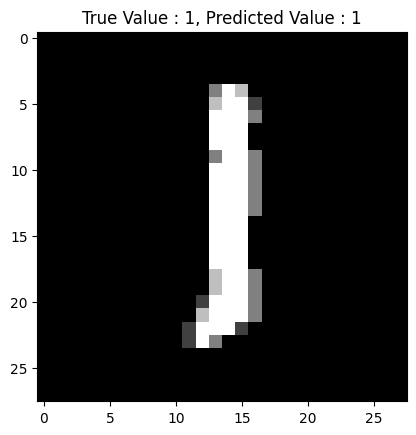

In [ ]:
# Dense Layers - Example 1 - MNIST Handwritten Digits Data

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Dense layers expect a 1D input, so whenever the preceding layer produces multi-dimensional output,
# We must flatten it to 1D before passing it to a Dense layer

# If the input to a Dense layer is not already 1D, use Flatten to convert it to 1D

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

predictions = model.predict(x_test)

plt.imshow(x_test[14], cmap='gray')
plt.title(f"True Value : {y_test[14]}, Predicted Value : {np.argmax(predictions[14])}")
plt.show()

In [ ]:
!pip install huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
import tensorflow as tf

model.save("mnist_model.keras")

In [ ]:
notebook_login()

In [ ]:
from huggingface_hub import HfApi

repo_id = "shubhamsingh123/mnist-model"
api = HfApi()

api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

RepoUrl('https://huggingface.co/shubhamsingh123/mnist-model', endpoint='https://huggingface.co', repo_type='model', repo_id='shubhamsingh123/mnist-model')

In [ ]:
from huggingface_hub import upload_folder

upload_folder(folder_path="", repo_id=repo_id, repo_type="model")
#

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ata/mnist_train_small.csv:  46%|####5     | 16.7MB / 36.5MB            

  ...ample_data/mnist_test.csv: 100%|##########| 18.3MB / 18.3MB            

  /content/mnist_model.keras  :  48%|####7     |  592kB / 1.24MB            

CommitInfo(commit_url='https://huggingface.co/shubhamsingh123/mnist-model/commit/0040db7662cb2b3f4dfefd08c3af25b6f142779d', commit_message='Upload folder using huggingface_hub', commit_description='', oid='0040db7662cb2b3f4dfefd08c3af25b6f142779d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/shubhamsingh123/mnist-model', endpoint='https://huggingface.co', repo_type='model', repo_id='shubhamsingh123/mnist-model'), pr_revision=None, pr_num=None)

In [ ]:
from tensorflow import keras
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(repo_id=repo_id, filename="mnist_model.keras")
model = keras.models.load_model(model_path)
model.summary()

mnist_model.keras:   0%|          | 0.00/1.24M [00:00<?, ?B/s]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [ ]:
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[3.1774665e-08, 5.3886717e-09, 1.7145559e-06, ..., 9.9998504e-01,
        2.7430003e-08, 2.0422563e-06],
       [8.3360625e-08, 7.3549713e-06, 9.9994761e-01, ..., 8.3257446e-13,
        7.7456280e-06, 4.8337254e-12],
       [9.3512813e-07, 9.9688107e-01, 1.2635000e-03, ..., 1.4052485e-03,
        3.7170344e-04, 7.4637264e-06],
       ...,
       [2.0581245e-12, 1.8718344e-10, 5.6068149e-12, ..., 4.8655156e-06,
        6.4704298e-05, 4.4571160e-04],
       [5.9630437e-08, 1.2984835e-09, 1.8250757e-11, ..., 9.1127134e-08,
        1.5455643e-04, 1.9828544e-08],
       [2.5611135e-09, 3.0702421e-13, 1.9208872e-09, ..., 5.3856783e-13,
        5.8889651e-12, 1.2654941e-10]], dtype=float32)